<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/t_value_H0_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**5. Prueba de hipótesis $H_0:\;\beta_j=0$**

Asumiendo la regresión
$$y=\beta_0+\beta_1 x_1+\beta_2 x_2+\dots+\beta_k x_k+u.$$
<br>

La **hipótesis nula** $H_0: \beta_j=0$.

<br>
Significa que  una vez que las demás variables $x_i\neq x_j$ han sido tomadas en cuenta, el "impacto" de la variable $x_j$  **no tiene efecto** sobre la variable $y$. En caso de rechazar $H_0$ tenemos las siguientes hipótesis alternas

* $H_1: \beta_j>0$, en tal caso la variable $x_j$ tiene un impacto positivo en $y$,

* $H_1: \beta_j< 0$, esto significa que variable $x_j$ tiene un impacto negativo en $y$,

La hipótesis nula plantea
$$H_0: \beta_j=0,$$
recordemos que $\beta_j$ no es observable, por lo tanto, nuestro objeto de análisis es el estimador insesgado $\widehat{\beta_j}$.
 En cualquier aplicación interesante, el estimador  $\widehat{\beta_j}$ nunca es exactamente cero, sea o no verdadera $H_0$. De modo que, planteamos medir

 <center>¿qué tan lejos está $\widehat{\beta_j}$ de cero?
 </center>

El error estándar de $\widehat{\beta_j}$ es una estimación de la desviación estándar de $\widehat{\beta_j}$, por otra pate, recordemos que $t_{\beta_j}$ mide a cuántas desviaciones estándar se encuentra $\widehat{\beta_j}$ de cero.


Si el valor de $t_{\widehat{\beta_j}}$ se encuentra suficientemente lejos de cero se rechazará $H_0$. El término "suficientemente" depende de la **hipótesis alternativa** $H_i$ y del **nivel de significancia** $\alpha$ elegido para la prueba.


* **Observa que:** estamos probando hipótesis acerca de **parámetros poblacionales** $\pmb{\beta_j}$ y no  acerca de estimaciones $\widehat{\beta_j}$; es decir,  si el valor poblacional desconocido $\beta_j$ es cero.
<br>

###**5.1 Regla de rechazo para $H_0$**

Considerando un **nivel de significancia $\alpha\%$**, este corresponde al **percentil** $1-\alpha$ de una **distribución-$t$ con $\pmb{n-(k+1)}$ gl** (grados de libertad) que denotamos $c_\alpha$. En otras palabras, rechazamos $H_0$ con nivel de significancia $\alpha\%$ si el estadístico $t_{\widehat{\beta_j}}$ es mayor que el **valor crítico** $c_\alpha$ para $\alpha$; en otros términos

$$\text{Si }\quad t_{\widehat{\beta_j}}>c_\alpha
\quad\Longrightarrow\quad
H_0:\;\beta_j=0\;\text{se rechaza}.$$

El valor crítico $c_\alpha$ se calcula de la [tablas de distribución](https://alumnosuacj-my.sharepoint.com/:b:/g/personal/ralmanza_uacj_mx/EfvZfgTK-qZNiNLB82lkZLkBkLTlMTkOf2T1u9BqBl209w?e=hq4nIs) t-Student, considerando un nivel de significancia $(1-\alpha)$ y $gl$-grados de libertad.


<br>

###**Ejemplo [tablas]:** Asumiendo un nivel de significancia de $\alpha=0.95$ y $20$-gl, para una prueda de una cola, se tiene el valor crítico $c_\alpha=1.725$.

**Observación:** Recuerda que la curva de la distribución t-Student es simétrica, por lo tanto, las tablas presentan los niveles de significancia tipicos y hay que considerar la simetría de la curva. Si nos interesa $\alpha=0.05$ y $20$-gl, el valor crítico estará del lado derecho de la curva; es decir, $c_\alpha=-1.725$


<br>

###**Ejemplo [python]:** En python el paquete `scipy.stats` incluye la función `st.t.ppf`($\alpha$,gl), donde $\alpha$ es el nivel de significancia y $gl$ son los grados de libertad.



```
import scipy.stats as st

st.t.ppf(.95,20)

st.t.ppf(.05,20)

```




## **1. Nivel de significancia y grados de libertad**

En la libreria `scipy.stats` se encuentra la función `t.ppf(alpha, gl)` que asigna **el valor crítico**, correspondiente al nivel de significancia=`alpha` y los grados de libertad=`gl` que queremos calcular.

In [ ]:
import scipy.stats as st

alpha01=st.t.ppf(.90,522)
alpha05=st.t.ppf(.95,522)
alpha001=st.t.ppf(.99,522)

print(f'critical val del 10%={alpha01:.4f}')
print(f'critical val del 5%={alpha05:.4f}')
print(f'critical val del 1%={alpha001:.4f}')

tval=2.391


critical val del 10%=1.2832
critical val del 5%=1.6478
critical val del 1%=2.3335


#**5.3 El p-value**

El $p-value$ lo obtenemo a partir de la distribución-$t$ asumiendo los $n-(k+1))$  grados de libertad, para determinar la probabilidad de observar un estadístico-$t$ más extremo que el $t_{\widehat{\beta_j}}$ calculado. El $p-value$ que presenta python es para una prueba de dos colas y esta definido como

$$p-value=(2\times P(T>|t_{\widehat{\beta_j}}|)),$$
donde $t_{\widehat{\beta_j}}$ es el estadístico-$t$ de la variable de interés.

Observemos que
$$P(T>|t_{\widehat{\beta_j}}|)$$
denota la probabilidad de encontrar valores $T$ mayores que el $t$-value del estimador $\widehat{\beta_j}$. El valor de esa probabilidad esta definido por la **función de distribución acomulada** (**CDF** por siglas en inglés), en `python` calculamos este valor con la función



```python
import scipy.stats as st

st.t.cdf(a,gl)
```
donde $a$ es el t-value de referencia y $gl$ son los grados de libertad. El resultado corresponde a la probabilidad acumulada desde $-\infty$ hasta el valor de referencia $a$, en otros términos, esto es
$$P[X\leq a]=\int_{-\infty}^af(x)dx.$$



###**5.4 Regla de rechazo de $H_0$ con el p-value**
La hipótesis nula sigue siendo que el coeficiente poblacional $\beta_j$ es cero, esto significa que no hay relación entre la variable independiente y la dependiente. El $p-value$ representa evidencia en contra la hipótesis nula, es necesario asumir un nivel de significancia (niv. sig.) $\alpha$, generalmente se asumen $\alpha=\{0.1,0.05$ y $0.01\}$


$$H_0:\;\beta_j=0,$$

* Se rechaza $H_0$ si $p-val(t_{\widehat{\beta_j}})\;<\;niv. sig. (\alpha)$.

* En caso de que  $p-val(t_{\widehat{\beta_j}})\;>\;niv. sig. (\alpha)$, se concluye que
"no existe suficiente evidencia para rechazar $H_0$".


###**Observación:** Si $p-val(t_{\widehat{\beta_j}})\;>\;niv. sig. (\alpha)$ es **incorrecto** decir "se acepta la hipótesis nula". Decir “aceptamos $H_0$” **sugiere falsamente que hemos probado que $H_0$ es verdadera**, lo cual **no es cierto**, porque:

* La falta de evidencia contra $H_0$ no implica que sea verdadera, solo que no hay evidencia suficiente para rechazarla.

* Siempre existe la posibilidad de un **error tipo II**: no rechazar una hipótesis nula que en realidad es falsa.


In [ ]:
import scipy.stats as st

prob=st.t.cdf(12.5552, 522)
p_value=2*(1-prob)

print(f'probabilidad acomulada del t-value={prob:.3f}')
print(f'p-vaue={p_value:.3f}')

probabilidad acomulada del t-value=1.000
p-vaue=0.000


# **5.1.2 Guardar gráficas `plt.savefig()`**

En las pruebas de hipótesis intervienen las curvas de distribución y en ocaciones resulta interesante incluirlas en los reportes. Para esto vamos a incluir una recomendación de como guardar estas gráficas con una mejor "calidad". Cuando incluimos "muchas" gráficas, es importante tener una carpeta (en Drive) donde guardar estos archivos. Para esto, montamos nuestro drive


```python
from google.colab import drive

drive.mount('/content/drive')
```
y definimos la ruta de la carpeta donde vamos guardar los archivos

```python
path='/content/drive/MyDrive/Colab Notebooks/0Figure/'
```

In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')
path='/content/drive/MyDrive/Colab Notebooks/0Figure/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##**Prueba de dos colas**

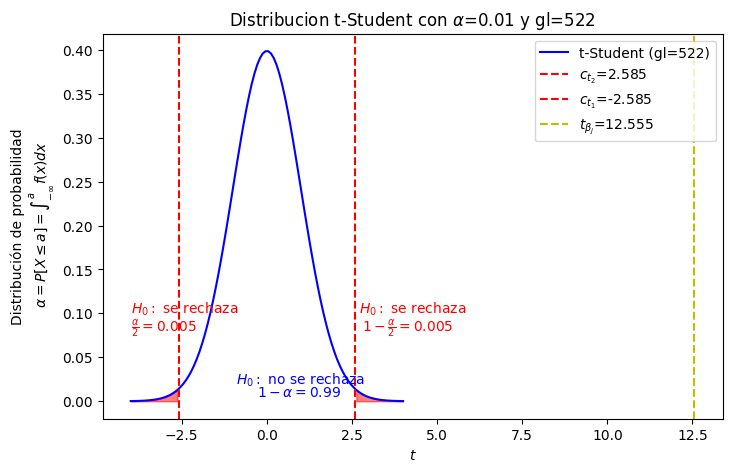

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


#   nivel de significancia
alpha=.01

#   Grados de libertad
#   Ya lo hemos definido con   '.df_resid'
gl=522
########       t-critico (1-cola)       ############
#      t-critico correspondiente a los gl de OLS
t_cr1=st.t.ppf(alpha/2, gl)
t_cr2=st.t.ppf(1-alpha/2, gl)


#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=12.5552


x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)

plt.figure(figsize=(8, 5))
plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr2, color='red', alpha=0.5)
plt.fill_between(x,tcurve, where=x<t_cr1, color='red', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr2, linestyle='dashed', color='r', label=r'$c_{t_2}$=' f'{t_cr2:.3f}')
plt.axvline(t_cr1, linestyle='dashed', color='r', label=r'$c_{t_1}$=' f'{t_cr1:.3f}')
#  estadistico-t
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$1-\alpha=$' f'{1-alpha:.2f}',c='b',fontsize=10)
plt.text(-4,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(-4,.08, r'$\frac{\alpha}{2}=$' f'{alpha/2:.3f}',c='r',fontsize=10)
plt.text(2.7,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$1-\frac{\alpha}{2}=$' f'{alpha/2:.3f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha} y gl={gl}')
plt.legend()

plt.savefig('curvaPDF2t.jpg')
#plt.savefig('curvaPDF2t.jpg', dpi=300, bbox_inches='tight')
#plt.savefig(path + 'curvaPDF2t.jpg', dpi=300, bbox_inches='tight')

plt.show()


##**Prueba de una cola**

In [ ]:
#   nivel de significancia
alpha=.99
gl=522

crit_v=st.t.ppf(alpha,gl)

print(f'nivel de significancia (alpha)={alpha:.2f}')

tBj=2.391

if tBj > crit_v:
    print(f'Dado que t-value={tBj:.4f}> crit-value={crit_v:.4f},\n se rechaza H0.')
else:
    print(f'Dado que t-value={tBj:.4f}< crit-value={crit_v:.4f},\n NO se rechaza H0.')


nivel de significancia (alpha)=0.99
Dado que t-value=2.3910> crit-value=2.3335,
 se rechaza H0.


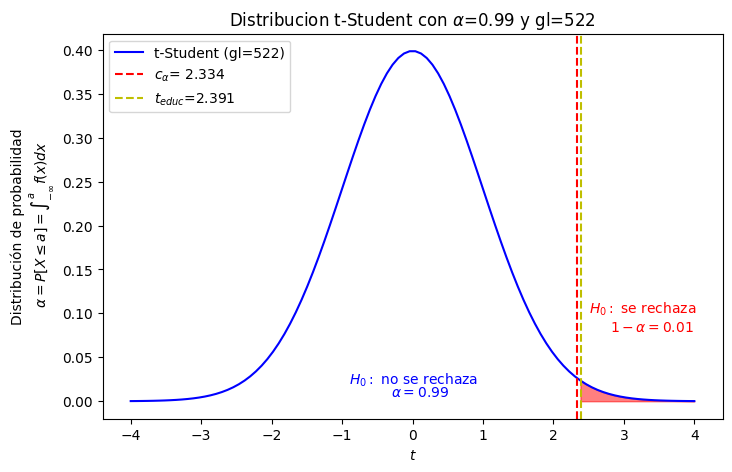

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st


#   nivel de significancia
alpha=.99

#   Grados de libertad
#   Ya lo hemos definido con   '.df_resid'
gl=522

########       t-critico (1-cola)       ############
#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)


#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=2.391
#t_tenure=tenure_t

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)

plt.figure(figsize=(8, 5))
plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr, color='red', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr, linestyle='dashed', color='r', label=rf'$c_\alpha$= {t_cr:.3f}')
#  estadistico-t-exper
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{educ}$=' f'{tBj:.3f}')
#  estadistico-t-tenure
#plt.axvline(t_tenure, linestyle='dashed', color='y', label=r'$t_{tenure}$=' f'{t_tenure:.3f}')


#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$\alpha=$' f'{alpha:.2f}',c='b',fontsize=10)
plt.text(2.5,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$1-\alpha=$' f'{1-alpha:.2f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha:.2f} y gl={gl}')
plt.legend()

#plt.savefig(path + 'curvaPDF.jpg', dpi=300, bbox_inches='tight')
#plt.savefig(path + 'curvaPDF2.jpg')


plt.show()


NameError: name 'path' is not defined

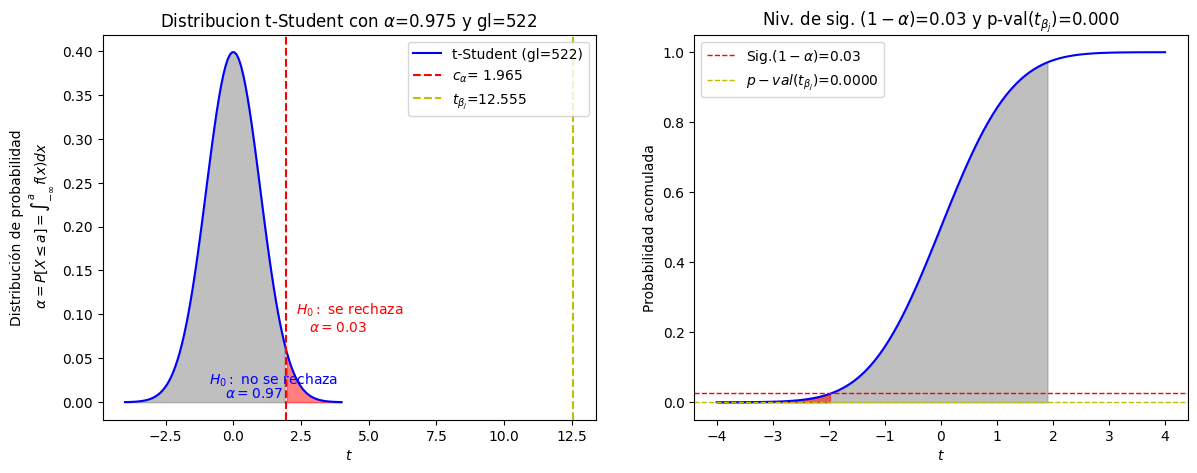

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

#   nivel de significancia
alpha=.975

#   gl lo hemos definido con   '.df_resid' /or/ agregalo manual
gl=522

#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)

#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=12.5552
p_tBj=st.t.cdf(tBj,gl)
p_vBj=2*(1-p_tBj)

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)
CDFcurve=st.t.cdf(x, gl)

# Graficando las distribuciones #
plt.figure(figsize = (14,5))
#############################################################
#                            (a)
#############################################################
plt.subplot(1,2,1)
#   Gráfica de curva PDF

plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x>t_cr, color='r', alpha=0.5)
plt.fill_between(x,tcurve, where=x<t_cr, color='gray', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr, linestyle='dashed', color='r', label=rf'$c_\alpha$= {t_cr:.3f}')
#  estadistico-t
plt.axvline(tBj, linestyle='dashed', color='y', label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$\alpha=$' f'{alpha:.2f}',c='b',fontsize=10)
plt.text(2.3,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(2.8,.08, r'$\alpha=$' f'{1-alpha:.2f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha} y gl={gl}')
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(x,CDFcurve,color='blue')  # label=f't-Student (gl={gl})'

#   Rango de rechazo de H_0
plt.fill_between(x,CDFcurve, where=x<=t_cr,color='gray',alpha=.5)
#plt.axvline(t_cr,color='r', linewidth=1,linestyle='dashed')   #  ,label=r'$t_\alpha$='f'{t_cr:.3f}'
#plt.axhline(alpha,color='r',linewidth=1,linestyle='dashed',label=r'$Pr(\alpha)$='f'{alpha:.2f}')
#plt.axhline(p_tBj,color="y",linewidth=1,linestyle="dashed", label=r'$Pr(t_{\beta_j})$='f'{p_tBj:.4f}')


#    p-value evaluacion
plt.fill_between(x,CDFcurve, where=(CDFcurve<(1-alpha))&(x<t_cr),color='red',alpha=.5)
plt.axhline((1-alpha),color='r',linewidth=1,linestyle='dashed',label=r'Sig.$(1-\alpha)$='f'{(1-alpha):.2f}')
plt.axhline(p_vBj,color="y",linewidth=1,linestyle="dashed", label=r'$p-val(t_{\beta_j})$='f'{p_vBj:.4f}')
#plt.axvline(tBj,color="y",linewidth=1,linestyle="dashed", label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

plt.xlabel(r'$t$')
plt.ylabel('Probabilidad acomulada')
plt.title(r'Niv. de sig. $(1-\alpha)$=' f'{1-alpha:.2f}'  r' y p-val($t_{\beta_j}$)='f'{p_vBj:.3f}')
plt.legend()

plt.savefig(path+'curvaPDF-CDF.jpg', dpi=300, bbox_inches='tight')


plt.show()